# Улучшение качества классификации

**Содержание:**

- Sampler с возвращением
- Sampler без возвращения
- Выводы и наблюдения

In [1]:
import pandas as pd
import numpy as np
import optuna
from sklearn.preprocessing import StandardScaler, LabelEncoder
from torch.utils.data import DataLoader, TensorDataset, WeightedRandomSampler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import matplotlib.pyplot as plt
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from sklearn.metrics import f1_score
from sklearn.utils.class_weight import compute_class_weight

from utils import plot_train_dynamics, create_sequences
from attention_gru import DetectorAttentionGRU

In [2]:
import warnings
for warn in [UserWarning, FutureWarning]: warnings.filterwarnings("ignore", category = warn)

In [3]:
DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

Группировка классов

In [4]:
data = pd.read_csv('Free_Text_EmoSurv.csv')

emotion_mapping = {
    0: 2,  # Angry -> Negative
    1: 1,  # Calm -> Positive
    2: 1,  # Happy -> Positive
    3: 0,  # Neutral -> Neutral
    4: 2   # Sad -> Negative
}

data['emotionIndex'] = data['emotionIndex'].map(emotion_mapping)

In [5]:
users = data['userid'].unique().tolist()
train_users, test_users = train_test_split(users, test_size = 0.3, random_state = 0) # делим на train и test по пользователям

train_data = data[data['userid'].isin(train_users)].copy()
test_data = data[data['userid'].isin(test_users)].copy()

test_users, valid_users = train_test_split(test_users, test_size = 0.5, random_state = 0) # дополнительно выделим валидационную выборку

test_data = data[data['userid'].isin(test_users)].copy()
valid_data = data[data['userid'].isin(valid_users)].copy()

feature_cols = ['D1U1', 'D1U2', 'D1D2', 'U1D2', 'U1U2', 'D1U3', 'D1D3', 'is_punctuation', 'is_backspace', 'is_enter', 'hour']

scaler_X = StandardScaler()
train_data[feature_cols] = scaler_X.fit_transform(train_data[feature_cols])
test_data[feature_cols] = scaler_X.transform(test_data[feature_cols])
valid_data[feature_cols] = scaler_X.transform(valid_data[feature_cols])

In [6]:
SEQ_LEN = 32  # длина последовательности
STEP = 16     # шаг для последовательности
X_train, y_train = create_sequences(train_data, SEQ_LEN, STEP, is_train = True)
X_test, y_test = create_sequences(test_data, SEQ_LEN, STEP)
X_valid, y_valid = create_sequences(valid_data, SEQ_LEN, STEP)

In [7]:
train_dataset = TensorDataset(X_train, y_train)
valid_dataset = TensorDataset(X_valid, y_valid)
test_dataset = TensorDataset(X_test, y_test)
 
valid_loader = DataLoader(valid_dataset, batch_size = 16, shuffle = False) 
test_loader = DataLoader(test_dataset, batch_size = 16, shuffle = False)   

In [8]:
train_labels = torch.tensor([y for _, y in train_dataset])
class_counts = torch.bincount(train_labels)

# веса для каждого обучающего примера
class_weights = len(train_labels) / (3 * class_counts.float())
sample_weights = class_weights[train_labels] 

## Sampler с возвращением

In [9]:
sampler = WeightedRandomSampler(
    weights=sample_weights,  # веса для каждого примера
    num_samples=len(sample_weights),  # сколько примеров выбрать за эпоху
    replacement=True  # можно ли выбирать один пример несколько раз
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    sampler = sampler
)

In [10]:
def model_analysis(model, total_epochs, model_optimizer, criterion, focal_loss = False):
    train_f1 = []
    train_loss = []

    for epoch in range(total_epochs):
        model.train()
        total_loss = 0
        targets, predictions = [], []
        
        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(DEVICE)
            y_batch = y_batch.to(DEVICE)

            model_optimizer.zero_grad()
            output = model(X_batch)
            
            if focal_loss == True:
                y_one_hot = F.one_hot(y_batch, num_classes=3).float() # конвертируем индексы в one-hot
                loss = criterion(output, y_one_hot)
            else:
                loss = criterion(output, y_batch)
            
            loss.backward()
            model_optimizer.step()

            preds = torch.argmax(output, dim = 1)
            total_loss += loss.item() * X_batch.size(0)
            targets.extend(y_batch.cpu().numpy())
            predictions.extend(preds.cpu().numpy())
        
        avg_loss = total_loss / len(train_loader.dataset)
        train_loss.append(avg_loss)
        f1 = f1_score(targets, predictions, average='macro')
        train_f1.append(f1)
        
        if epoch % 10 == 9 or epoch == 0:
            print(f'Epoch {epoch+1}/{total_epochs}, Loss: {avg_loss:.6f}')
        
    return train_loss, train_f1

In [11]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.004, weight_decay = 1e-4)
criterion = nn.CrossEntropyLoss()

train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 1.092174
Epoch 10/40, Loss: 1.029883
Epoch 20/40, Loss: 1.012547
Epoch 30/40, Loss: 0.968604
Epoch 40/40, Loss: 0.930911


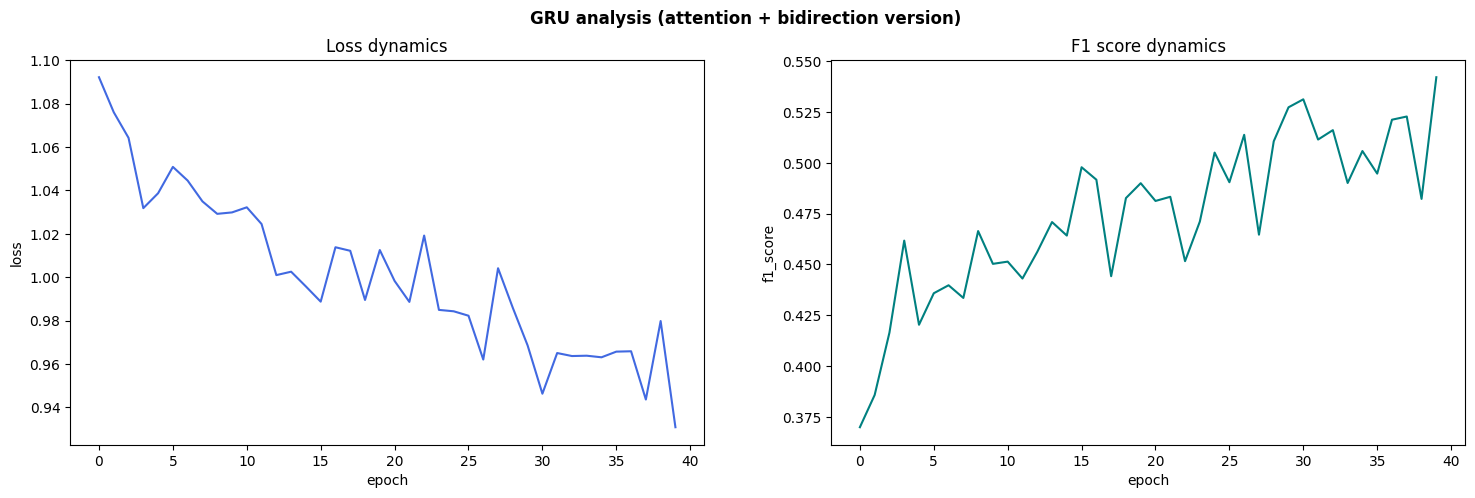

In [12]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

In [13]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.39      0.17      0.24        63
    Positive       0.37      0.29      0.33        45
    Negative       0.17      0.48      0.25        25

    accuracy                           0.27       133
   macro avg       0.31      0.31      0.27       133
weighted avg       0.34      0.27      0.27       133



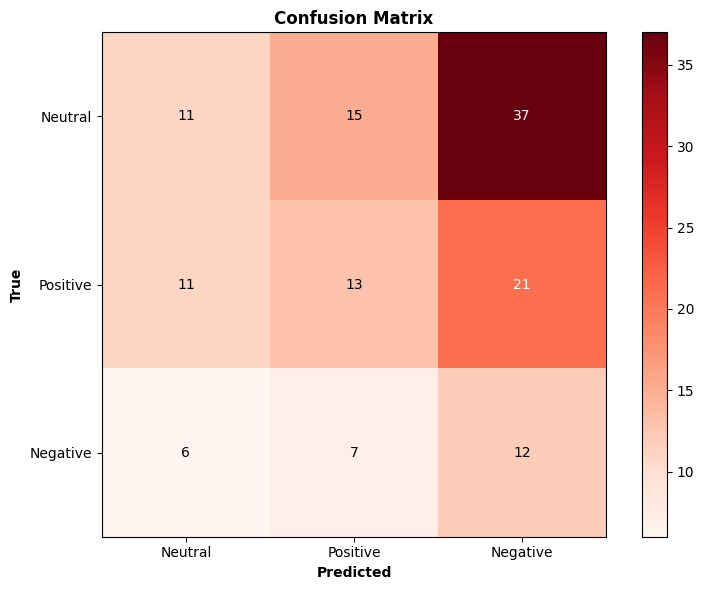

In [14]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

## Sampler без возвращения

In [36]:
sampler = WeightedRandomSampler(
    weights=sample_weights,  # веса для каждого примера
    num_samples=len(sample_weights),  # сколько примеров выбрать за эпоху
    replacement=False  # можно ли выбирать один пример несколько раз
)

train_loader = DataLoader(
    train_dataset,
    batch_size = 64,
    sampler = sampler
)

In [81]:
attn_model_bidirect = DetectorAttentionGRU(input_size = 11, hidden_size = 16, num_layers = 1,  num_classes = 3, dropout = 0.3, bidirectional = True).to(DEVICE)
optimizer = optim.Adam(attn_model_bidirect.parameters(), lr = 0.005)
criterion = nn.CrossEntropyLoss()

train_loss_attn_b, train_f1_attn_b = model_analysis(attn_model_bidirect, 40, optimizer, criterion)

Epoch 1/40, Loss: 1.009153
Epoch 10/40, Loss: 0.959439
Epoch 20/40, Loss: 0.920617
Epoch 30/40, Loss: 0.889432
Epoch 40/40, Loss: 0.875080


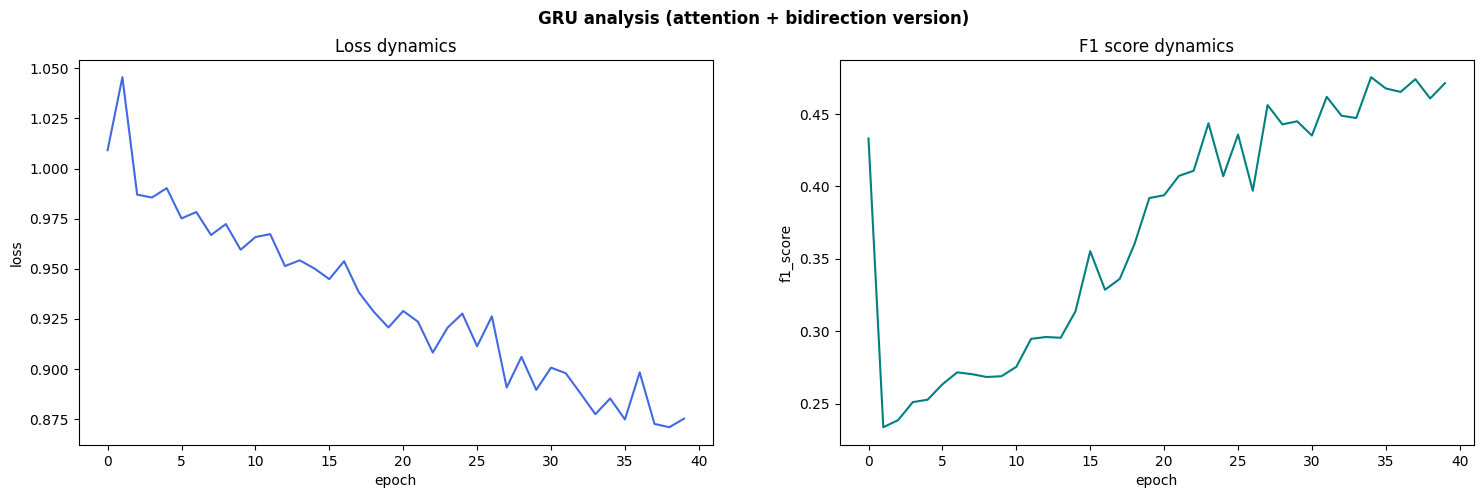

In [82]:
fig = plot_train_dynamics(attn_model_bidirect, train_loss_attn_b, train_f1_attn_b, 'GRU analysis (attention + bidirection version)')
plt.show(fig)

In [83]:
pred = attn_model_bidirect(X_test)       # логиты
y_pred = pred.argmax(dim=1).detach().cpu().numpy()

print(classification_report(y_test, y_pred, target_names=['Neutral', 'Positive', 'Negative']))

              precision    recall  f1-score   support

     Neutral       0.48      0.75      0.59        63
    Positive       0.67      0.04      0.08        45
    Negative       0.21      0.28      0.24        25

    accuracy                           0.42       133
   macro avg       0.45      0.36      0.30       133
weighted avg       0.49      0.42      0.35       133



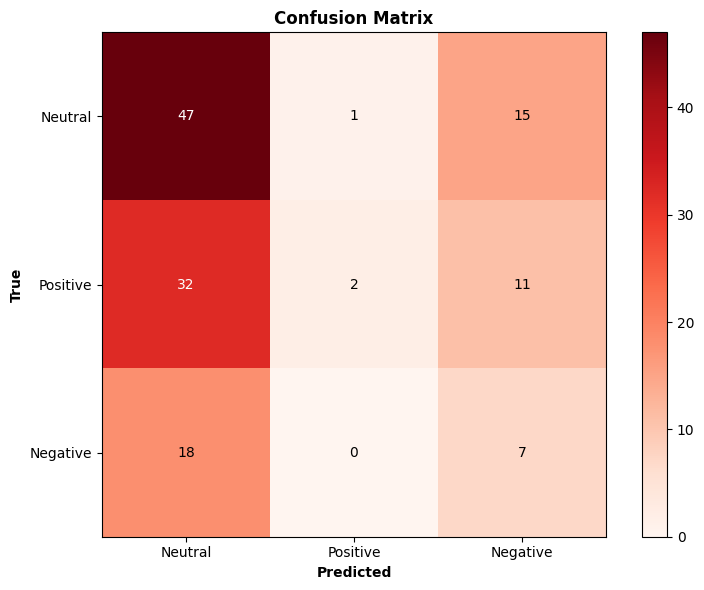

In [84]:
matrix = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(8, 6))
plt.imshow(matrix, interpolation='nearest', cmap='Reds')
plt.colorbar()

plt.xticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.yticks(range(len(matrix)), ['Neutral', 'Positive', 'Negative'])
plt.xlabel("Predicted", fontweight='bold')
plt.ylabel("True", fontweight='bold')
plt.title("Confusion Matrix", fontweight='bold')

for i in range(matrix.shape[0]):
    for j in range(matrix.shape[1]):
        plt.text(
            j, i, str(matrix[i, j]),
            ha="center", va="center",
            color="white" if matrix[i, j] > matrix.max() / 2 else "black"
        )

plt.tight_layout()
plt.show()

## Выводы и наблюдения

**Sampler c возвращением**

- Слишком агрессивный метод для борьбы с дисбалансом классов. Искусственное увеличение количества примеров редкого класса Negative путем их повторения заставляет модель "запоминать" эти конкретные примеры, а не обобщать

**Sampler без возвращения**

- Модель в основном предсказывает самый частый класс, практически не распознает класс Positive